In [23]:
# install the dependencies (pandas, numpy, openpyxl for .xlsx, ...)
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn -q

# import the dependencies
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
# Rolling sales by borough: one Excel file per NYC borough under ./data
DATA_DIR = Path("data")

# (display name, filename) — values must be borough labels, not paths alone
BOROUGH_FILES = [
    ("Bronx", "rollingsales_bronx.xlsx"),
    ("Brooklyn", "rollingsales_brooklyn.xlsx"),
    ("Manhattan", "rollingsales_manhattan.xlsx"),
    ("Queens", "rollingsales_queens.xlsx"),
    ("Staten Island", "rollingsales_statenisland.xlsx"),
]

borough_frames: dict[str, pd.DataFrame] = {}
for borough, fname in BOROUGH_FILES:
    path = DATA_DIR / fname
    # First 4 rows are title/description; real table header starts on row 5
    df = pd.read_excel(path, skiprows=4)

    print(f"Shape of {borough} data: {df.shape}")

    borough_frames[borough] = df

# Remove any rows where the sale price is 0 or negative or missing
for borough in borough_frames:
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"].notna()]
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"] > 0]

sales = pd.concat(borough_frames.values(), ignore_index=True)

sales.shape, list(borough_frames.keys())

Shape of Bronx data: (6498, 21)
Shape of Brooklyn data: (22641, 21)
Shape of Manhattan data: (19163, 21)
Shape of Queens data: (26385, 21)
Shape of Staten Island data: (7036, 21)


((53956, 21), ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'])

In [25]:
# Dropping irrelevant columns
columns_to_drop = ["BOROUGH", "APARTMENT NUMBER", "EASEMENT"]
for borough in borough_frames:
    try:
        borough_frames[borough] = borough_frames[borough].drop(columns=columns_to_drop)
    except KeyError:
        pass  # column already absent in this frame

In [26]:


# How empty is each column in each borough?
def is_nullish(s: pd.Series) -> pd.Series:
    null = s.isna()
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        return null
    empty_str = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    return null | empty_str

# Fill in missing values for residential, commercial, and total units
for borough in borough_frames:
    df = borough_frames[borough]
    for idx, row in df.iterrows():
        residential_units = row["RESIDENTIAL UNITS"]
        commercial_units = row["COMMERCIAL UNITS"]
        total_units = row["TOTAL UNITS"]

        r_ok = pd.notna(residential_units) and not (
            isinstance(residential_units, str) and residential_units.strip() == ""
        )
        c_ok = pd.notna(commercial_units) and not (
            isinstance(commercial_units, str) and commercial_units.strip() == ""
        )
        t_ok = pd.notna(total_units) and not (
            isinstance(total_units, str) and total_units.strip() == ""
        )

        if not r_ok and t_ok and c_ok:
            residential_units = total_units - commercial_units
        elif not t_ok and r_ok and c_ok:
            total_units = residential_units + commercial_units
        elif not c_ok and t_ok and r_ok:
            commercial_units = total_units - residential_units

        df.loc[idx, "RESIDENTIAL UNITS"] = residential_units
        df.loc[idx, "COMMERCIAL UNITS"] = commercial_units
        df.loc[idx, "TOTAL UNITS"] = total_units

# Rebuild combined frame so later analysis sees imputed unit columns
sales = pd.concat(borough_frames.values(), ignore_index=True)

for borough in borough_frames:
    print(f"Percentage of empty values in {borough} data:")
    for col in borough_frames[borough].columns:
        pct = is_nullish(borough_frames[borough][col]).mean()
        print(f"{col}: {pct}")
    print()

Percentage of empty values in Bronx data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.22034296452901103
COMMERCIAL UNITS: 0.22034296452901103
TOTAL UNITS: 0.22034296452901103
LAND SQUARE FEET: 0.30913789053323937
GROSS SQUARE FEET: 0.30913789053323937
YEAR BUILT: 0.09701667841202725
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0

Percentage of empty values in Brooklyn data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 7.126060001425212e-05
RESIDENTIAL UNITS: 0.16183282263236656
COMMERCIAL UNITS: 0.16183282263236656
TOTAL UNITS: 0.16183282263236656
LAND SQUARE FEET: 0.45934582769186916
GROSS SQUARE FEET: 0.45934582769186916
YEAR BUILT: 0.06719874581343975
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF

In [27]:
# Work with manhattan coops (exclude categories that also contain CONDO, e.g. CONDO COOPS)
_bcc = borough_frames["Manhattan"]["BUILDING CLASS CATEGORY"].astype(str).str.upper()
manhattan_condos = borough_frames["Manhattan"][_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")]

# Total number of rentals
print("Total number of rentals:")
print(manhattan_condos.shape[0])

# See what different Building class categories are there
print("Building class categories:")
print(manhattan_condos["BUILDING CLASS CATEGORY"].unique())

# see the columns one more time
print(manhattan_condos.columns)

Total number of rentals:
6918
Building class categories:
<StringArray>
[             '11 SPECIAL CONDO BILLING LOTS',
              '12 CONDOS - WALKUP APARTMENTS',
            '13 CONDOS - ELEVATOR APARTMENTS',
          '15 CONDOS - 2-10 UNIT RESIDENTIAL',
                   '46 CONDO STORE BUILDINGS',
 '16 CONDOS - 2-10 UNIT WITH COMMERCIAL UNIT',
                       '28 COMMERCIAL CONDOS',
                  '43 CONDO OFFICE BUILDINGS',
                           '44 CONDO PARKING',
              '47 CONDO NON-BUSINESS STORAGE',
          '48 CONDO TERRACES/GARDENS/CABANAS',
  '42 CONDO CULTURAL/MEDICAL/EDUCATIONAL/ETC',
                            '45 CONDO HOTELS',
                      '04 TAX CLASS 1 CONDOS',
          '49 CONDO WAREHOUSES/FACTORY/INDUS']
Length: 15, dtype: str
Index(['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
       'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOT

In [28]:
# print the head
print(manhattan_condos.head())

     NEIGHBORHOOD          BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
71  ALPHABET CITY    11 SPECIAL CONDO BILLING LOTS                    2   
72  ALPHABET CITY    12 CONDOS - WALKUP APARTMENTS                    2   
74  ALPHABET CITY    12 CONDOS - WALKUP APARTMENTS                    2   
78  ALPHABET CITY  13 CONDOS - ELEVATOR APARTMENTS                    2   
79  ALPHABET CITY  13 CONDOS - ELEVATOR APARTMENTS                    2   

    BLOCK   LOT BUILDING CLASS AT PRESENT                      ADDRESS  \
71    397  1301                        RR   250 EAST HOUSTON STREET, 1   
72    394  1203                        R2     615 EAST 11TH STREET, B1   
74    405  1207                        R2       511 EAST 11 STREET, A3   
78    384  1215                        R4  310 EAST HOUSTON STREET, 5A   
79    392  1022                        R4             143 AVENUE B, 6A   

    ZIP CODE  RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL UNITS  \
71     10002              132.0       

In [29]:
# Print the columsn that are entirely null
print(manhattan_condos.columns[manhattan_condos.isna().all()])

# remove any columsn that are entirely null
manhattan_condos = manhattan_condos.dropna(axis=1, how="all")

# print the head
print(manhattan_condos.head())

Index([], dtype='str')
     NEIGHBORHOOD          BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
71  ALPHABET CITY    11 SPECIAL CONDO BILLING LOTS                    2   
72  ALPHABET CITY    12 CONDOS - WALKUP APARTMENTS                    2   
74  ALPHABET CITY    12 CONDOS - WALKUP APARTMENTS                    2   
78  ALPHABET CITY  13 CONDOS - ELEVATOR APARTMENTS                    2   
79  ALPHABET CITY  13 CONDOS - ELEVATOR APARTMENTS                    2   

    BLOCK   LOT BUILDING CLASS AT PRESENT                      ADDRESS  \
71    397  1301                        RR   250 EAST HOUSTON STREET, 1   
72    394  1203                        R2     615 EAST 11TH STREET, B1   
74    405  1207                        R2       511 EAST 11 STREET, A3   
78    384  1215                        R4  310 EAST HOUSTON STREET, 5A   
79    392  1022                        R4             143 AVENUE B, 6A   

    ZIP CODE  RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL UNITS  \
71     10002   

In [30]:
# print out what percent of each column is null
for col in manhattan_condos.columns:
    print(f"{col}: {manhattan_condos[col].isna().mean()}")

NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.0
COMMERCIAL UNITS: 0.0
TOTAL UNITS: 0.0
LAND SQUARE FEET: 0.9978317432784042
GROSS SQUARE FEET: 0.9978317432784042
YEAR BUILT: 0.1688349233882625
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0


In [31]:
# Remove LSF and GSF columns
manhattan_condos = manhattan_condos.drop(columns=["LAND SQUARE FEET", "GROSS SQUARE FEET"])

# print the head
print(manhattan_condos.head())

     NEIGHBORHOOD          BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
71  ALPHABET CITY    11 SPECIAL CONDO BILLING LOTS                    2   
72  ALPHABET CITY    12 CONDOS - WALKUP APARTMENTS                    2   
74  ALPHABET CITY    12 CONDOS - WALKUP APARTMENTS                    2   
78  ALPHABET CITY  13 CONDOS - ELEVATOR APARTMENTS                    2   
79  ALPHABET CITY  13 CONDOS - ELEVATOR APARTMENTS                    2   

    BLOCK   LOT BUILDING CLASS AT PRESENT                      ADDRESS  \
71    397  1301                        RR   250 EAST HOUSTON STREET, 1   
72    394  1203                        R2     615 EAST 11TH STREET, B1   
74    405  1207                        R2       511 EAST 11 STREET, A3   
78    384  1215                        R4  310 EAST HOUSTON STREET, 5A   
79    392  1022                        R4             143 AVENUE B, 6A   

    ZIP CODE  RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL UNITS  YEAR BUILT  \
71     10002              

In [32]:
# Time & place: walkup vs elevator, neighborhood, vintage (rebuilt from Manhattan so we keep BCC)
REF_YEAR = 2026

m = borough_frames["Manhattan"].copy()
_bcc = m["BUILDING CLASS CATEGORY"].astype(str).str.upper()
coop_tp = m[_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")].copy()

coop_tp["SALE DATE"] = pd.to_datetime(coop_tp["SALE DATE"])
bcc_upper = coop_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
coop_tp["COOP_TYPE"] = np.where(
    bcc_upper.str.contains("WALKUP"),
    "Walkup",
    np.where(bcc_upper.str.contains("ELEVATOR"), "Elevator", "Other"),
)

coop_tp["YEAR BUILT"] = pd.to_numeric(coop_tp["YEAR BUILT"], errors="coerce")
coop_tp["BUILDING_AGE"] = REF_YEAR - coop_tp["YEAR BUILT"]

# Match earlier notebook: upper-tail IQR trim on sale price (coop slice)
q1 = coop_tp["SALE PRICE"].quantile(0.25)
q3 = coop_tp["SALE PRICE"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
coop_tp = coop_tp[coop_tp["SALE PRICE"] < upper_fence].copy()

coop_tp["YEAR"] = coop_tp["SALE DATE"].dt.year
coop_tp["MONTH"] = coop_tp["SALE DATE"].dt.month
coop_tp["YEAR_MONTH"] = coop_tp["SALE DATE"].dt.to_period("M")
coop_tp["QUARTER"] = coop_tp["SALE DATE"].dt.to_period("Q")

print("COOP_TYPE counts:\n", coop_tp["COOP_TYPE"].value_counts(), sep="")
print(f"\nRows after upper IQR trim: {len(coop_tp):,}")
print(
    f"Sale date range: {coop_tp['SALE DATE'].min().date()} – {coop_tp['SALE DATE'].max().date()}"
)
print(f"Neighborhoods: {coop_tp['NEIGHBORHOOD'].nunique()}")


COOP_TYPE counts:
COOP_TYPE
Elevator    5286
Other        676
Walkup        63
Name: count, dtype: int64

Rows after upper IQR trim: 6,025
Sale date range: 2025-03-03 – 2026-02-27
Neighborhoods: 39


In [33]:
# Comparable outcomes: total sale price vs price per residential unit; how "big" each deal is
ru = pd.to_numeric(coop_tp["RESIDENTIAL UNITS"], errors="coerce")
sp = coop_tp["SALE PRICE"].astype(float)
coop_tp["PRICE_PER_RES_UNIT"] = np.where(ru > 0, sp / ru, np.nan)
coop_tp["DEAL_SCOPE"] = np.where(
    ru.isna() | (ru <= 0),
    "Unknown/missing units",
    np.where(ru == 1, "Single unit (likely apartment sale)", "Multi-unit / bulk"),
)

bcc = coop_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
cond_special = bcc.str.contains("SPECIAL CONDO BILLING")
cond_comm = bcc.str.contains(
    "CONDO STORE|CONDO OFFICE|CONDO HOTEL|COMMERCIAL CONDO|CONDO PARKING|WAREHOUSE|FACTORY|"
    "NON-BUSINESS STORAGE|TERRACES|CULTURAL|MEDICAL|EDUCATIONAL"
)
cond_res = bcc.str.contains(
    "WALKUP|ELEVATOR|2-10 UNIT|TAX CLASS 1 CONDOS"
)
coop_tp["BCC_SEGMENT"] = np.select(
    [cond_special, cond_comm, cond_res],
    ["Special billing lots", "Commercial / non-housing", "Residential (walkup/elevator/small)"],
    default="Other / unclassified",
)

print("DEAL_SCOPE:\n", coop_tp["DEAL_SCOPE"].value_counts(), sep="")
print("\nBCC_SEGMENT:\n", coop_tp["BCC_SEGMENT"].value_counts(), sep="")

DEAL_SCOPE:
DEAL_SCOPE
Single unit (likely apartment sale)    5577
Unknown/missing units                   437
Multi-unit / bulk                        11
Name: count, dtype: int64

BCC_SEGMENT:
BCC_SEGMENT
Residential (walkup/elevator/small)    5574
Commercial / non-housing                437
Special billing lots                     14
Name: count, dtype: int64


In [34]:
# How total price and $/unit differ by deal type, building segment, and elevator vs walkup
key = ["DEAL_SCOPE", "BCC_SEGMENT", "COOP_TYPE"]

def _summarize(df: pd.DataFrame, label: str) -> None:
    print(f"\n=== {label} (n={len(df):,}) ===")
    for col in ["SALE PRICE", "PRICE_PER_RES_UNIT"]:
        s = df[col].dropna()
        if len(s) == 0:
            print(f"{col}: no values")
            continue
        print(
            f"{col}: median={s.median():,.0f}  mean={s.mean():,.0f}  "
            f"p25={s.quantile(0.25):,.0f}  p75={s.quantile(0.75):,.0f}"
        )

_summarize(coop_tp, "All rows (IQR-trimmed)")

single = coop_tp[coop_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()
_summarize(single, "Single-unit deals only (best for $/unit comparability)")

print("\n--- Median SALE PRICE by BCC_SEGMENT × COOP_TYPE (all IQR-trimmed rows) ---")
print(
    coop_tp.pivot_table(
        values="SALE PRICE",
        index="BCC_SEGMENT",
        columns="COOP_TYPE",
        aggfunc="median",
    ).round(0)
)


=== All rows (IQR-trimmed) (n=6,025) ===
SALE PRICE: median=1,537,000  mean=2,097,361  p25=880,000  p75=2,770,000
PRICE_PER_RES_UNIT: median=1,523,642  mean=2,085,946  p25=890,000  p75=2,749,456

=== Single-unit deals only (best for $/unit comparability) (n=5,577) ===
SALE PRICE: median=1,525,000  mean=2,089,997  p25=895,000  p75=2,750,000
PRICE_PER_RES_UNIT: median=1,525,000  mean=2,089,997  p25=895,000  p75=2,750,000

--- Median SALE PRICE by BCC_SEGMENT × COOP_TYPE (all IQR-trimmed rows) ---
COOP_TYPE                             Elevator      Other    Walkup
BCC_SEGMENT                                                        
Commercial / non-housing                   NaN  1780000.0       NaN
Residential (walkup/elevator/small)  1510000.0  2530000.0  860000.0
Special billing lots                       NaN  1224674.0       NaN


/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_12516/80131906.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coop_tp, x="COOP_TYPE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_12516/80131906.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coop_tp, x="BCC_SEGMENT", y="SALE PRICE", showfliers=False, ax=ax, palette="muted")


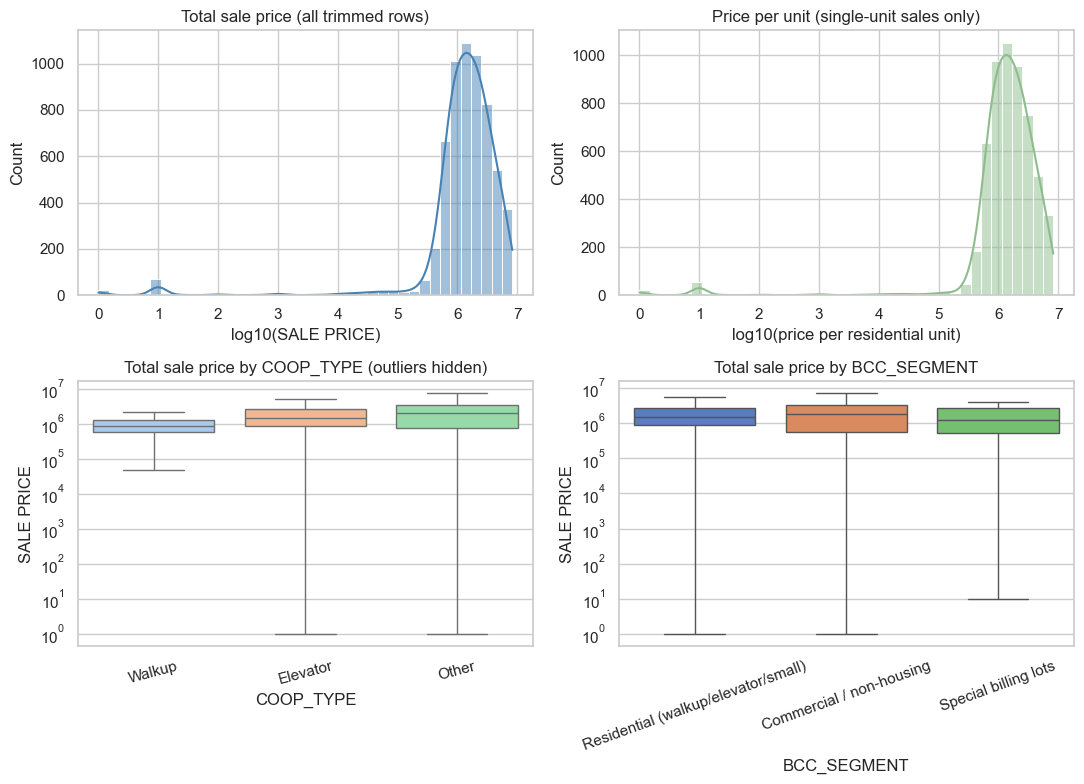

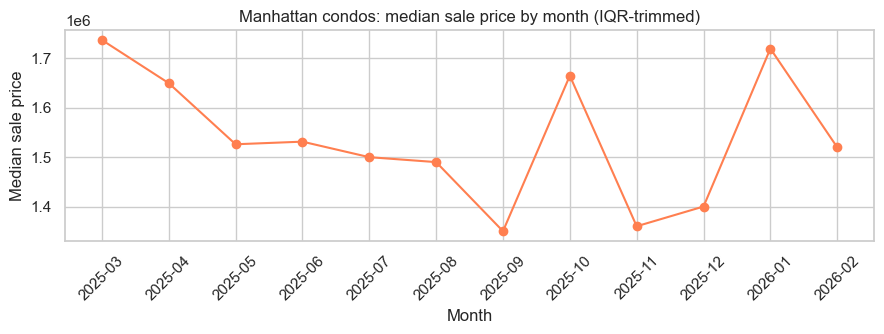

In [35]:
# Distributions: log scale for skewed prices; single-unit subset for $/unit
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
sns.histplot(np.log10(coop_tp["SALE PRICE"]), bins=40, kde=True, ax=ax, color="steelblue")
ax.set_xlabel("log10(SALE PRICE)")
ax.set_title("Total sale price (all trimmed rows)")

ax = axes[0, 1]
su = single["PRICE_PER_RES_UNIT"].dropna()
if len(su) > 0:
    sns.histplot(np.log10(su), bins=40, kde=True, ax=ax, color="darkseagreen")
    ax.set_xlabel("log10(price per residential unit)")
    ax.set_title("Price per unit (single-unit sales only)")
else:
    ax.set_title("No single-unit rows")

ax = axes[1, 0]
sns.boxplot(data=coop_tp, x="COOP_TYPE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
ax.set_yscale("log")
ax.set_title("Total sale price by COOP_TYPE (outliers hidden)")
ax.tick_params(axis="x", rotation=15)

ax = axes[1, 1]
sns.boxplot(data=coop_tp, x="BCC_SEGMENT", y="SALE PRICE", showfliers=False, ax=ax, palette="muted")
ax.set_yscale("log")
ax.set_title("Total sale price by BCC_SEGMENT")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Time: monthly median price (short window — interpret as seasonal/noisy, not long-run trend)
monthly = (
    coop_tp.groupby("YEAR_MONTH", sort=True)["SALE PRICE"]
    .median()
    .reset_index(name="median_price")
)
monthly["YEAR_MONTH"] = monthly["YEAR_MONTH"].astype(str)

fig2, ax2 = plt.subplots(figsize=(9, 3.5))
ax2.plot(monthly["YEAR_MONTH"], monthly["median_price"], marker="o", color="coral")
ax2.set_ylabel("Median sale price")
ax2.set_xlabel("Month")
ax2.set_title("Manhattan condos: median sale price by month (IQR-trimmed)")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Hedonic-style association: log(SALE PRICE) on single-unit sales only
# (Interpret as partial correlations / fit, not causal.)
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

reg_df = coop_tp[coop_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()
reg_df = reg_df.dropna(subset=["SALE PRICE", "BUILDING_AGE"])
reg_df = reg_df[reg_df["BUILDING_AGE"] > 0]  # need valid age for slope
reg_df["QUARTER_STR"] = reg_df["QUARTER"].astype(str)

y = np.log(reg_df["SALE PRICE"].to_numpy())
cat_cols = ["COOP_TYPE", "BCC_SEGMENT", "QUARTER_STR"]
num_cols = ["BUILDING_AGE"]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)
pipe = Pipeline([("prep", pre), ("ols", LinearRegression())])
pipe.fit(reg_df[cat_cols + num_cols], y)
r2 = pipe.score(reg_df[cat_cols + num_cols], y)

feat_names = pipe.named_steps["prep"].get_feature_names_out()
coefs = pipe.named_steps["ols"].coef_
intercept = pipe.named_steps["ols"].intercept_

print(f"Single-unit rows in regression: {len(reg_df):,}")
print(f"R² (log price): {r2:.3f}")
print(f"Intercept: {intercept:.4f}")
print("\nCoefficients (log $ per unit change in covariate):")
for name, c in zip(feat_names, coefs):
    print(f"  {name}: {c:.5f}")

Single-unit rows in regression: 4,620
R² (log price): 0.018
Intercept: 14.2913

Coefficients (log $ per unit change in covariate):
  cat__COOP_TYPE_Other: 0.51468
  cat__COOP_TYPE_Walkup: -0.20127
  cat__BCC_SEGMENT_Special billing lots: 0.50560
  cat__QUARTER_STR_2025Q2: 0.11136
  cat__QUARTER_STR_2025Q3: 0.01426
  cat__QUARTER_STR_2025Q4: -0.05508
  cat__QUARTER_STR_2026Q1: 0.16356
  num__BUILDING_AGE: -0.00527
